# NUMERICAL RANDOM SAMPLE IMPUTATION

In [1]:
import numpy as np 
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\ML\DataSet\Titanic_Dataset.csv",usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [3]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [4]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train_alpha,X_test_alpha,y_train_alpha,y_test_alpha = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
X_train.sample(3)

,Age,Fare
694,60.0,26.5500
118,24.0,247.5208
658,23.0,13.0000


In [7]:
X_train.isnull().mean()*100

Age     20.786517
Fare     0.000000
dtype: float64

In [8]:
X_test.isnull().mean()*100

Age     16.201117
Fare     0.000000
dtype: float64

In [9]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [10]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [11]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = (X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values)
X_test.loc[X_test['Age_imputed'].isnull(),'Age_imputed'] = (X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values)


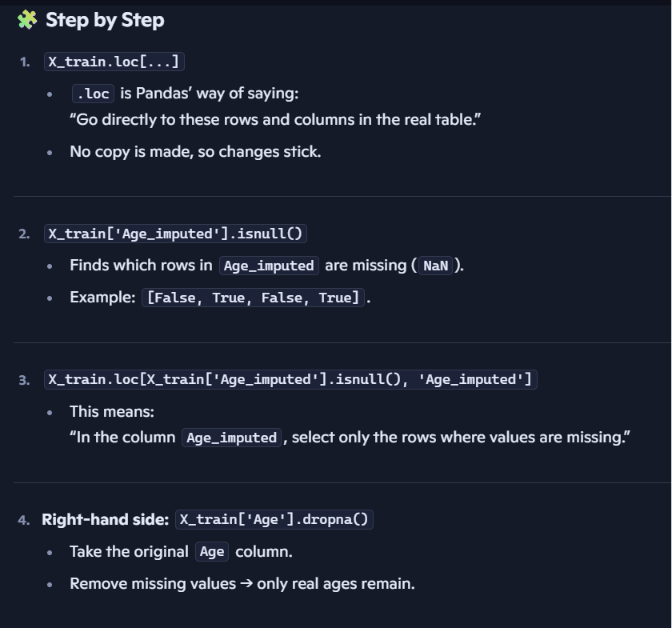
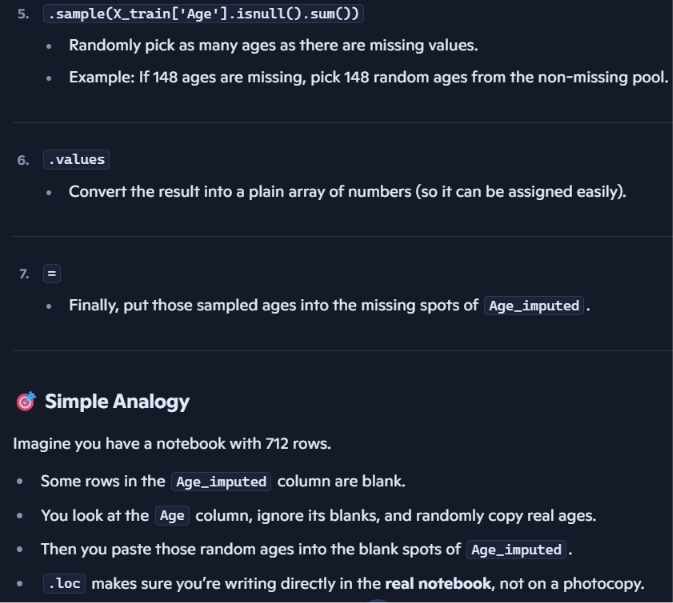

In [12]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([43. , 16. , 13. , 26. , 22. , 40. , 47. , 23. , 27. , 15. , 18. ,
       48. , 60. , 24. , 24. , 30. , 54. , 24. , 40. , 25. , 36.5, 19. ,
       23. , 36. , 26. , 19. , 28. , 30. , 20. , 28. , 27. , 54. , 45. ,
       39. , 32. , 21. , 22. , 38. , 32. , 23. , 18. , 22. , 45. , 54. ,
       17. , 27. , 24. ,  6. , 36. , 60. , 22. , 29. , 23. , 36. , 26. ,
       24. , 27. , 22. , 34. , 63. , 20. , 65. , 48. , 45.5, 29. , 31. ,
       40. , 22. , 17. , 21. , 23. , 25. , 30. , 20. , 50. , 29. , 25. ,
       24. , 27. , 16. , 25. , 44. , 52. , 33. ,  4. , 16. , 22. , 24. ,
       27. , 51. , 41. , 33. , 28. ,  4. , 24. ,  6. , 21. , 19. , 22. ,
       18. , 28. ,  9. , 42. , 32. , 65. , 58. , 33. , 18. , 16. , 47. ,
       48. , 39. , 29. , 32. , 21. , 39. , 19. , 42. , 16. , 29. , 11. ,
       54. , 31. , 20. , 32.5, 54. , 31. , 30.5, 50. , 45. ,  1. , 31. ,
       25. , 30. , 33. , 14. , 36. , 45. , 33. , 21. , 39. , 28.5, 16. ,
       28. , 41. , 29. , 19. ,  4. ])

In [13]:
X_train['Age'].isnull().sum()

np.int64(148)

In [14]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,42.0
493,71.0,49.5042,71.0
527,NaN,221.7792,46.0


C:\Users\Asus\AppData\Local\Temp\ipykernel_33260\2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\Asus\AppData\Local\Temp\ipykernel_33260\2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['A

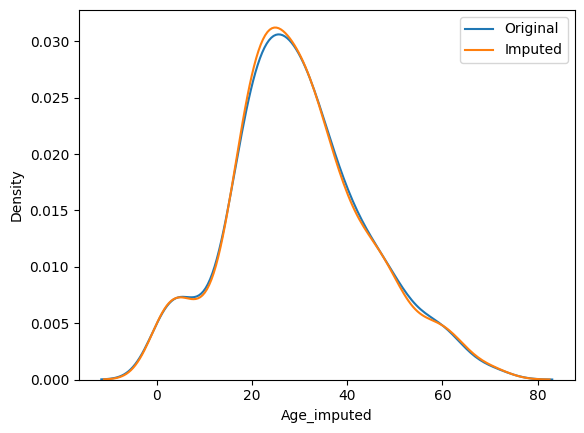

In [15]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

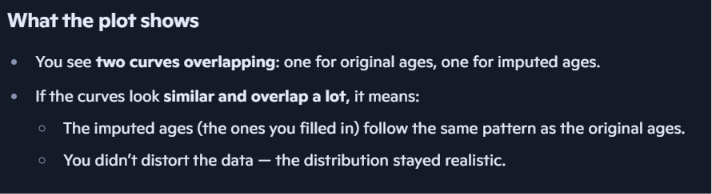

In [16]:
print('Original variable variance :', X_train['Age'].var())
print('Variance after random imputation :', X_train['Age_imputed'].var())

Original variable variance : 204.34951339046142
Variance after random imputation : 204.08991785900537


In [17]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,57.657872
Age,71.512440,204.349513,204.349513
Age_imputed,57.657872,204.349513,204.089918


<Axes: >

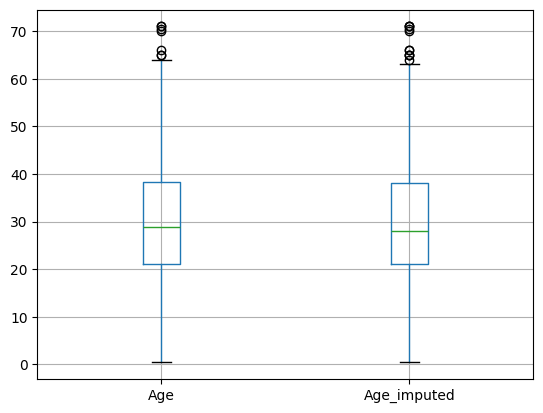

In [18]:
X_train[['Age', 'Age_imputed']].boxplot()   #this imputation doesn't have much impact on outliers.

now, from the above code, we observe that we have different output even for the same input. So we have to sort that.

In [19]:
# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare'])) #this doesn't work as observation in not defined

#instead use the below code

sampled_value = X_train['Age'].dropna().sample(1,random_state=42)

till now, we have studied about random-sample-imputation for numerical. Now it's time for 

# CATEGORICAL RANDOM SAMPLE IMPUTATION

In [20]:
data = pd.read_csv(r"D:/ML/DataSet/train_day37.csv",usecols=['GarageQual','FireplaceQu','SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [21]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [22]:
X1 = data   #we taking thee whole dataset as we will use this later on in plotting the graph
y1 = data['SalePrice']

In [23]:
X1.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [24]:
X1_train,X1_test,y1_train,y1_test = train_test_split(X1,y1,test_size=0.2,random_state=42)

In [25]:
X1_train.shape,X1_test.shape

((1168, 3), (292, 3))

In [26]:
X1_train['GarageQual_imputed'] = X1_train['GarageQual']
X1_test['GarageQual_imputed'] = X1_test['GarageQual']

X1_train['FireplaceQu_imputed'] = X1_train['FireplaceQu']
X1_test['FireplaceQu_imputed'] = X1_test['FireplaceQu']

In [27]:
X1_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1338,NaN,TA,200000,TA,NaN
786,NaN,TA,139000,TA,NaN
299,Gd,TA,158500,TA,Gd
1324,Gd,TA,147000,TA,Gd
151,Gd,TA,372402,TA,Gd


In [28]:
# X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
# X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

# X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
# X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values


X1_train.loc[X1_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (X1_train['GarageQual'].dropna().sample(X1_train['GarageQual'].isnull().sum()).values)
X1_test.loc[X1_test['GarageQual_imputed'].isnull(),'GarageQual_imputed'] = (X1_train['GarageQual'].dropna().sample(X1_test['GarageQual'].isnull().sum()).values)

X1_train.loc[X1_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (X1_train['FireplaceQu'].dropna().sample(X1_train['FireplaceQu'].isnull().sum()).values)
X1_test.loc[X1_test['FireplaceQu_imputed'].isnull(),'FireplaceQu_imputed'] = (X1_train['FireplaceQu'].dropna().sample(X1_test['FireplaceQu'].isnull().sum()).values)


In [29]:
#now we will check the freuency whether it changes much or not

temp = pd.concat(
        [
            X1_train['GarageQual'].value_counts() / len(X1_train['GarageQual'].dropna()),
            X1_train['GarageQual_imputed'].value_counts() / len(X1_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [30]:
temp

,original,imputed
TA,0.951087,0.950342
Fa,0.032609,0.032534
Gd,0.011775,0.011986
Ex,0.002717,0.003425
Po,0.001812,0.001712


In [31]:
temp = pd.concat(
        [
            X1_train['FireplaceQu'].value_counts() / len(X1_train['FireplaceQu'].dropna()),
            X1_train['FireplaceQu_imputed'].value_counts() / len(data)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp        #this shows a large changes so it is a red flag that this technique will not work in this case

,original,imputed
Gd,0.491143,0.391096
TA,0.405797,0.328082
Fa,0.043478,0.033562
Ex,0.033816,0.026027
Po,0.025765,0.021233


C:\Users\Asus\AppData\Local\Temp\ipykernel_33260\170962798.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X1_train[X1_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Asus\AppData\Local\Temp\ipykernel_33260\170962798.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6

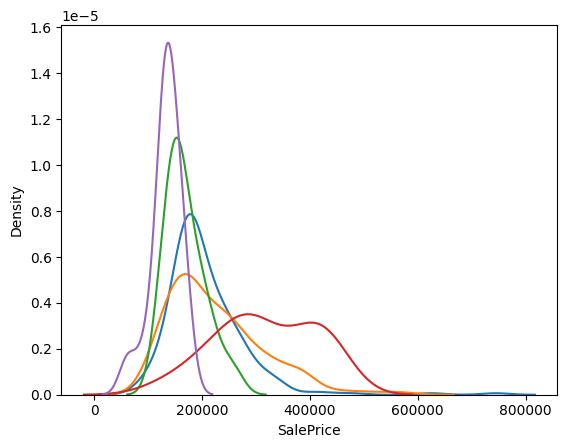

In [32]:
#we can make sure that this error will not occur by plotting the 2 graph(this code and code just below this)

for category in X1_train['FireplaceQu'].dropna().unique():
    sns.distplot(X1_train[X1_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_33260\348103782.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X1_train[X1_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Asus\AppData\Local\Temp\ipykernel_33260\348103782.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed29

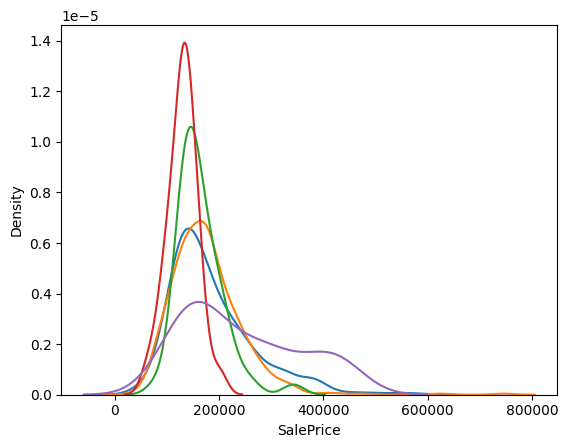

In [33]:
for category in X1_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X1_train[X1_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()

code explaination 

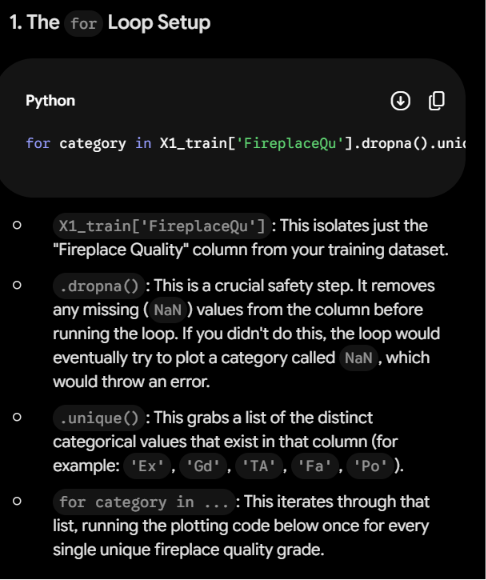

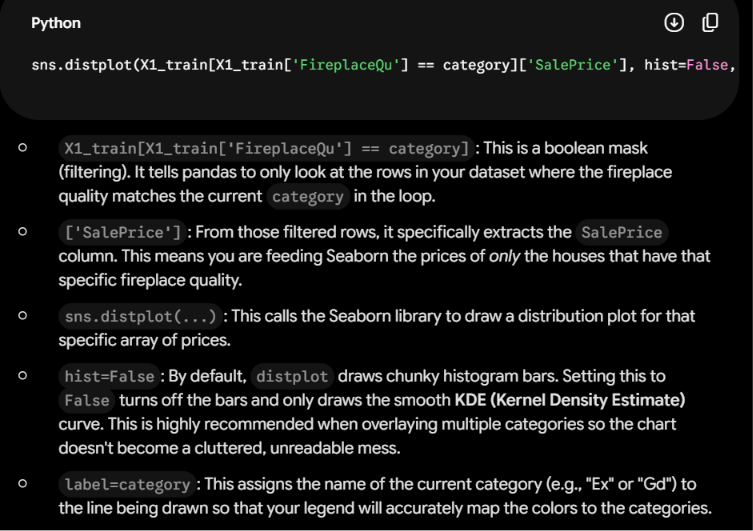

-----
-----
# Missing Indicators

In [34]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.impute import MissingIndicator,SimpleImputer   #this is the way to import 2 different libraries from same module

In [35]:
df2 = pd.read_csv(r"D:/ML/DataSet/Titanic_Dataset.csv",usecols=['Age','Fare','Survived'])

In [36]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [37]:
X2 = df2.drop(columns=['Survived'])
y2 = df2['Survived']

In [38]:
X2_train,X2_test,y2_train,y2_test = train_test_split(X2,y2,test_size=0.2,random_state=43)

In [39]:
X2_train.head(3)

,Age,Fare
826,NaN,56.4958
838,32.0,56.4958
763,36.0,120.0000


first we will study than how this willwork and the accuracy without missing indicator and then we will go towards missing imputer

In [40]:
si = SimpleImputer()
X2_train_trf = si.fit_transform(X2_train)
X2_test_trf = si.transform(X2_test)

In [41]:
X2_train_trf

array([[ 30.16725217,  56.4958    ],
       [ 32.        ,  56.4958    ],
       [ 36.        , 120.        ],
       ...,
       [ 29.        ,  15.2458    ],
       [ 22.        ,   7.25      ],
       [ 21.        ,   8.6625    ]], shape=(712, 2))

In [42]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X2_train_trf,y2_train)

y2_pred = clf.predict(X2_test_trf)
y2_pred

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0])

In [43]:
from sklearn.metrics import accuracy_score
accuracy_score(y2_test,y2_pred)

0.6536312849162011

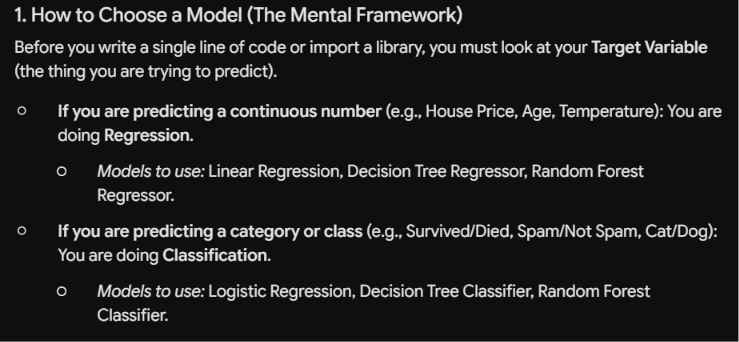

now lets us look for Missing Indicator impact

In [44]:
mi = MissingIndicator()
mi.fit(X2_train)

,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"features features: {'missing-only', 'all'}, default='missing-only'Whether the imputer mask should represent all or a subset offeatures.- If `'missing-only'` (default), the imputer mask will only represent features containing missing values during fit time.- If `'all'`, the imputer mask will represent all features.",'missing-only'
,"sparse sparse: bool or 'auto', default='auto'Whether the imputer mask format should be sparse or dense.- If `'auto'` (default), the imputer mask will be of same type as input.- If `True`, the imputer mask will be a sparse matrix.- If `False`, the imputer mask will be a numpy array.",'auto'
,"error_on_new error_on_new: bool, default=TrueIf `True`, :meth:`transform` will raise an error when there arefeatures with missing values that have no missing values in:meth:`fit`. This is applicable only when `features='missing-only'`.",True


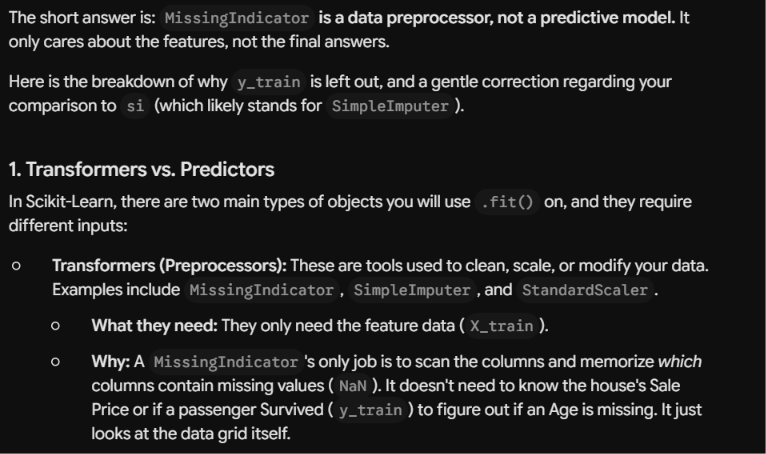
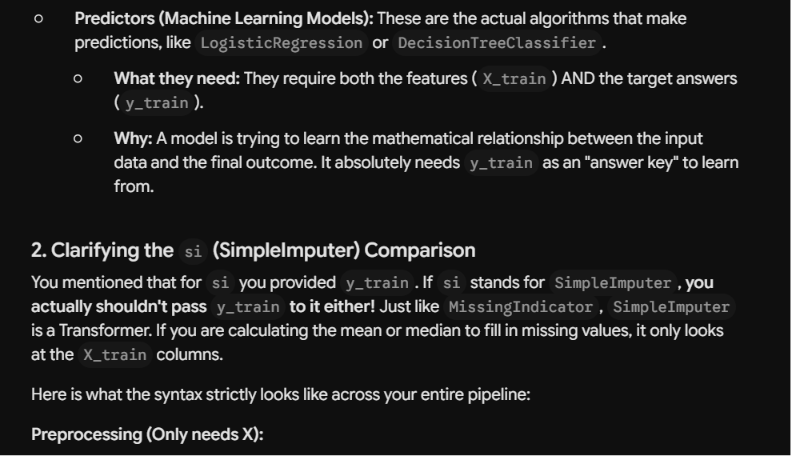

In [45]:
mi.features_    #this tells us that which column contains the missing values

array([0])

In [46]:
X2_train_missing = mi.transform(X2_train)
X2_test_missing = mi.transform(X2_test)

In [47]:
X2_train_missing

array([[ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [48]:
X2_train['Age_NA'] = X2_train_missing       #we are here creating a new column which will act as indicator and we are storing the missing indicator values in that column
X2_test['Age_NA'] = X2_test_missing

In [49]:
X2_train

,Age,Fare,Age_NA
826,NaN,56.4958,True
838,32.0,56.4958,False
763,36.0,120.0000,False
189,36.0,7.8958,False
109,NaN,24.1500,True
...,...,...,...
277,NaN,0.0000,True
817,31.0,37.0042,False
255,29.0,15.2458,False
320,22.0,7.2500,False


In [50]:
si = SimpleImputer()
X2_train_trf2 = si.fit_transform(X2_train)
X2_test_trf2 = si.transform(X2_test)

In [51]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X2_train_trf2,y2_train)

y2_pred2 = clf.predict(X2_test_trf2)
y2_pred2

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0])

In [52]:
from sklearn.metrics import accuracy_score
accuracy_score(y2_test,y2_pred2)

#last case result - 0.6536312849162011      #you can observe slight changes

0.659217877094972

----

this missing indicator become so much famous that even sklearn included it as a parameter, we don't have to write the whole code again and again

In [53]:
si = SimpleImputer(add_indicator=True)

In [54]:
X3_train = si.fit_transform(X_train_alpha)
X3_test = si.transform(X_test_alpha)

In [55]:
X3_train    # 1 = True => value was originally missing

array([[ 40.        ,  27.7208    ,   0.        ],
       [  4.        ,  16.7       ,   0.        ],
       [ 47.        ,   9.        ,   0.        ],
       ...,
       [ 71.        ,  49.5042    ,   0.        ],
       [ 29.78590426, 221.7792    ,   1.        ],
       [ 29.78590426,  25.925     ,   1.        ]], shape=(712, 3))

In [56]:
X3_train = pd.DataFrame(X3_train,columns=['Age','Fare','Age_NA'])
X3_test = pd.DataFrame(X3_test,columns=['Age','Fare','Age_NA'])


In [57]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X3_train,y_train_alpha)

y_pred3 = clf.predict(X3_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test_alpha, y_pred3)

0.6312849162011173

-----
-----